# Counting the Breaks — a quantitative teardown \U0001F52C
### Kupiec · Christoffersen · joint conditional coverage · a power curve nobody prints

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The two failure
modes — a distribution of the wrong shape, and a model blind to today's volatility — produce the
same breach count and need different tests to separate. The synthetic control turns each on
independently.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from breaks import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
spy = assets[data.EQUITY]
print(f"as-of {data.AS_OF} | {len(assets)} assets")
for tk, s in assets.items():
    print(f"  {tk:9s} {s.index[0].date()} -> {s.index[-1].date()}  n={len(s):,}  "
          f"worst day {s.min():.1%}  kurtosis {s.kurtosis():.1f}")

as-of 2026-06-30 | 6 assets
  SPY       1993-02-01 -> 2026-06-30  n=7,764  worst day -9.8%  kurtosis 11.3
  QQQ       1999-03-11 -> 2026-06-30  n=6,222  worst day -9.2%  kurtosis 6.9
  TLT       2002-07-31 -> 2026-06-30  n=5,371  worst day -6.7%  kurtosis 3.4
  GLD       2004-11-19 -> 2026-06-30  n=4,789  worst day -10.3%  kurtosis 6.9
  EEM       2003-04-15 -> 2026-06-30  n=5,193  worst day -16.2%  kurtosis 17.9
  BTC-USD   2014-09-18 -> 2026-06-30  n=4,304  worst day -37.2%  kurtosis 7.9


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | At 99% confidence over 6 assets, the textbook **normal** VaR model breached on **1.95%** of days against a promised 1.00% — 1.9× too often — and Kupiec's coverage test rejected it on **100%** of assets. Worse, and this is the part standard practice never checks: the independence test rejected it on **83%**, with runs of up to 4 consecutive breaches. Those are two different failures — the distribution's shape is wrong *and* it does not know today's volatility — and a breach count alone cannot tell them apart. The best model here is **ewma** at 1.79%, passing the joint test on 17% of assets. |
| **Tradability** | Partial | Before switching models on this evidence, note how weak the evidence can be. With 5,282 sessions at 99%, a model that breaches **50% too often** (1.5% instead of 1.0%) is caught by Kupiec only **91%** of the time; detecting that reliably needs about **3,536 sessions** — 14 years. On the days the models were wrong they were wrong by a lot: the normal model's average breach overshot its own forecast by 40%, and its worst day lost 37.2% against a forecast of 8.3%. Breach counting says nothing about that, which is the argument for expected shortfall. |

> \U0001F4A1 **In plain words.** The models fail in two distinguishable ways, and the test that
> distinguishes them is the one nobody runs.

## 1 · Hypotheses

- **H₁ (coverage).** Each model's breach rate equals 1 − *p*. Kupiec's LR test.
- **H₂ (independence).** Breaches are serially independent. Christoffersen's Markov LR test.
- **H₃ (joint).** Both, tested together at 2 df.
- **H₄ (diagnosis).** Fat tails and volatility clustering are *separable* failures: a model can
  fail H₁ from shape alone, or H₂ from conditioning alone.
- **H₅ (power).** With realistic sample sizes, these tests cannot reject a moderately wrong
  model — so passing them is weak evidence.

## 2 · The five forecasters, and the peek check

Before any grading: every model must be strictly out of sample. The tamper test below rewrites
the second half of the return series and confirms the first half's forecasts do not move.

In [3]:
r_ok = st.synthetic_returns(n=2000)
r_bad = r_ok.copy(); r_bad.iloc[1500:] *= 10
for m in st.MODELS:
    a = st.build_var(r_ok, m).iloc[:1400].dropna()
    b = st.build_var(r_bad, m).iloc[:1400].dropna()
    print(f"{m:22s} identical on the untouched half: {np.allclose(a, b)}")

historical             identical on the untouched half: True
normal                 identical on the untouched half: True


student_t              identical on the untouched half: True
ewma                   identical on the untouched half: True
filtered_historical    identical on the untouched half: True


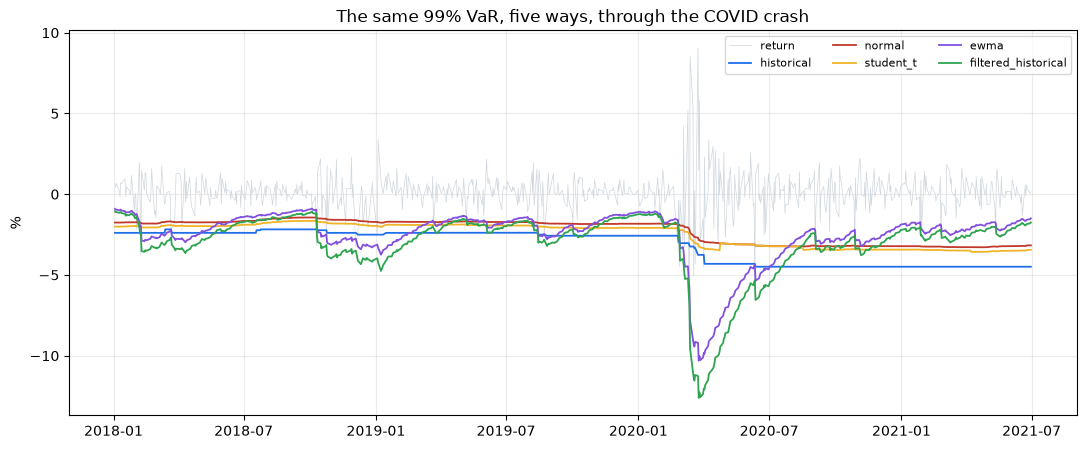

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
sl = slice("2018-01-01", "2021-06-30")
ax.plot(spy.loc[sl].index, spy.loc[sl] * 100, lw=0.5, color="#d0d7de", label="return")
for m, c in zip(st.MODELS, ["#1f6feb", "#c0392b", "#f0b429", "#8250df", "#2ea44f"]):
    v = st.build_var(spy, m, 0.99, 500).loc[sl]
    ax.plot(v.index, -v * 100, lw=1.3, color=c, label=m)
ax.set_ylabel("%"); ax.legend(fontsize=8, ncol=3)
ax.set_title("The same 99% VaR, five ways, through the COVID crash")
plt.show()

> \U0001F4A1 **In plain words.** Watch March 2020. The conditional models (EWMA, FHS) leap; the
> unconditional ones (historical, normal) barely move for weeks. That lag *is* the clustering
> failure, drawn.

## 3 · The teardown

### 3.1 Every model, every asset

In [5]:
rows = []
for tk, s in assets.items():
    g = st.grade_all(s, 0.99, 500)
    for m, rr in g.iterrows():
        rows.append({"asset": tk, "model": m, **{k: rr[k] for k in
                     ("n", "breaches", "expected", "rate", "kupiec_p", "independence_p",
                      "joint_p", "max_consecutive", "mean_excess")}})
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))

  asset               model          n  breaches  expected   rate  kupiec_p  independence_p  joint_p  max_consecutive  mean_excess
    SPY          historical 7,264.0000  107.0000   72.6400 0.0147    0.0002          0.0000   0.0000           2.0000       0.3792
    SPY              normal 7,264.0000  165.0000   72.6400 0.0227    0.0000          0.0001   0.0000           2.0000       0.4632
    SPY           student_t 7,263.0000  129.0000   72.6300 0.0178    0.0000          0.0001   0.0000           2.0000       0.4062
    SPY                ewma 7,264.0000  140.0000   72.6400 0.0193    0.0000          0.2000   0.0000           2.0000       0.3945
    SPY filtered_historical 7,264.0000  147.0000   72.6400 0.0202    0.0000          0.2734   0.0000           2.0000       0.3623
    QQQ          historical 5,722.0000   70.0000   57.2200 0.0122    0.1009          0.0000   0.0000           4.0000       0.3156
    QQQ              normal 5,722.0000  121.0000   57.2200 0.0211    0.0000        

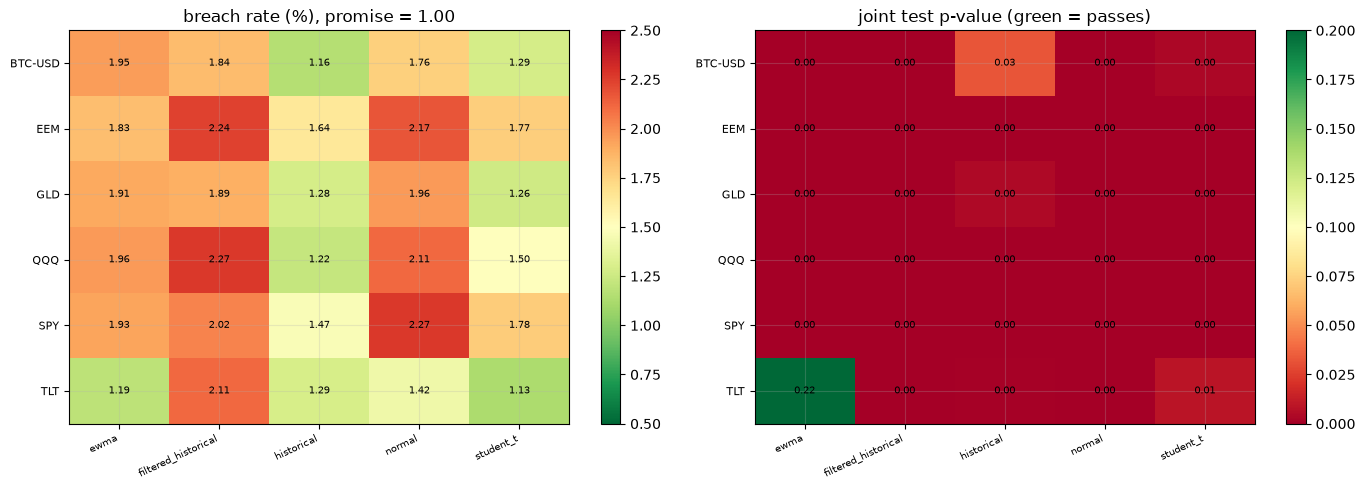

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
piv = d.pivot(index="asset", columns="model", values="rate").mul(100)
im = axes[0].imshow(piv.values, cmap="RdYlGn_r", vmin=0.5, vmax=2.5, aspect="auto")
axes[0].set_xticks(range(piv.shape[1]))
axes[0].set_xticklabels(piv.columns, rotation=25, ha="right", fontsize=7)
axes[0].set_yticks(range(piv.shape[0])); axes[0].set_yticklabels(piv.index, fontsize=8)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f"{piv.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[0].set_title("breach rate (%), promise = 1.00")
fig.colorbar(im, ax=axes[0])
piv2 = d.pivot(index="asset", columns="model", values="joint_p")
im2 = axes[1].imshow(piv2.values, cmap="RdYlGn", vmin=0, vmax=0.2, aspect="auto")
axes[1].set_xticks(range(piv2.shape[1]))
axes[1].set_xticklabels(piv2.columns, rotation=25, ha="right", fontsize=7)
axes[1].set_yticks(range(piv2.shape[0])); axes[1].set_yticklabels(piv2.index, fontsize=8)
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]):
        axes[1].text(j, i, f"{piv2.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[1].set_title("joint test p-value (green = passes)")
fig.colorbar(im2, ax=axes[1])
plt.tight_layout(); plt.show()

### 3.2 Separating the two failures

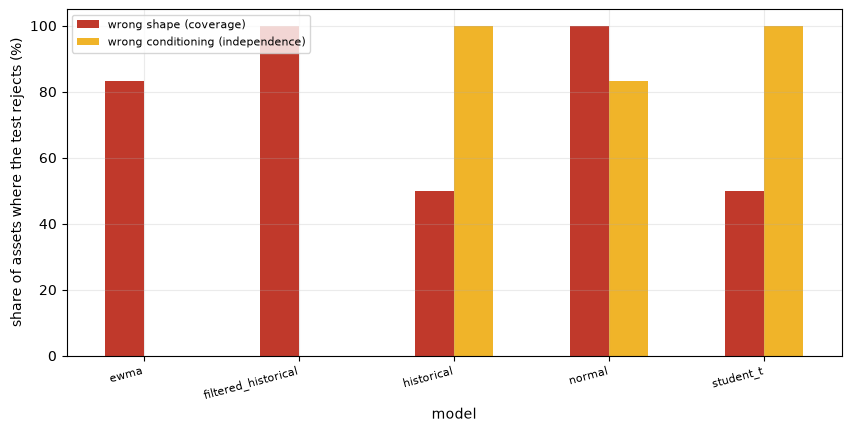

,coverage fails,independence fails
model,,
ewma,0.8330,0.0000
filtered_historical,1.0000,0.0000
historical,0.5000,1.0000
normal,1.0000,0.8330
student_t,0.5000,1.0000


In [7]:
rows = []
for tk, s in assets.items():
    for m in st.MODELS:
        g = st.grade_model(s, m, 0.99, 500)
        rows.append({"asset": tk, "model": m,
                     "coverage fails": g["kupiec_p"] < 0.05,
                     "independence fails": g["independence_p"] < 0.05})
d2 = pd.DataFrame(rows)
tab = d2.groupby("model")[["coverage fails", "independence fails"]].mean()
fig, ax = plt.subplots(figsize=(10, 4.5))
tab.mul(100).plot.bar(ax=ax, color=["#c0392b", "#f0b429"])
ax.set_ylabel("share of assets where the test rejects (%)")
ax.legend(["wrong shape (coverage)", "wrong conditioning (independence)"], fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
plt.show()
tab.round(3)

### 3.3 Clustering, seen directly

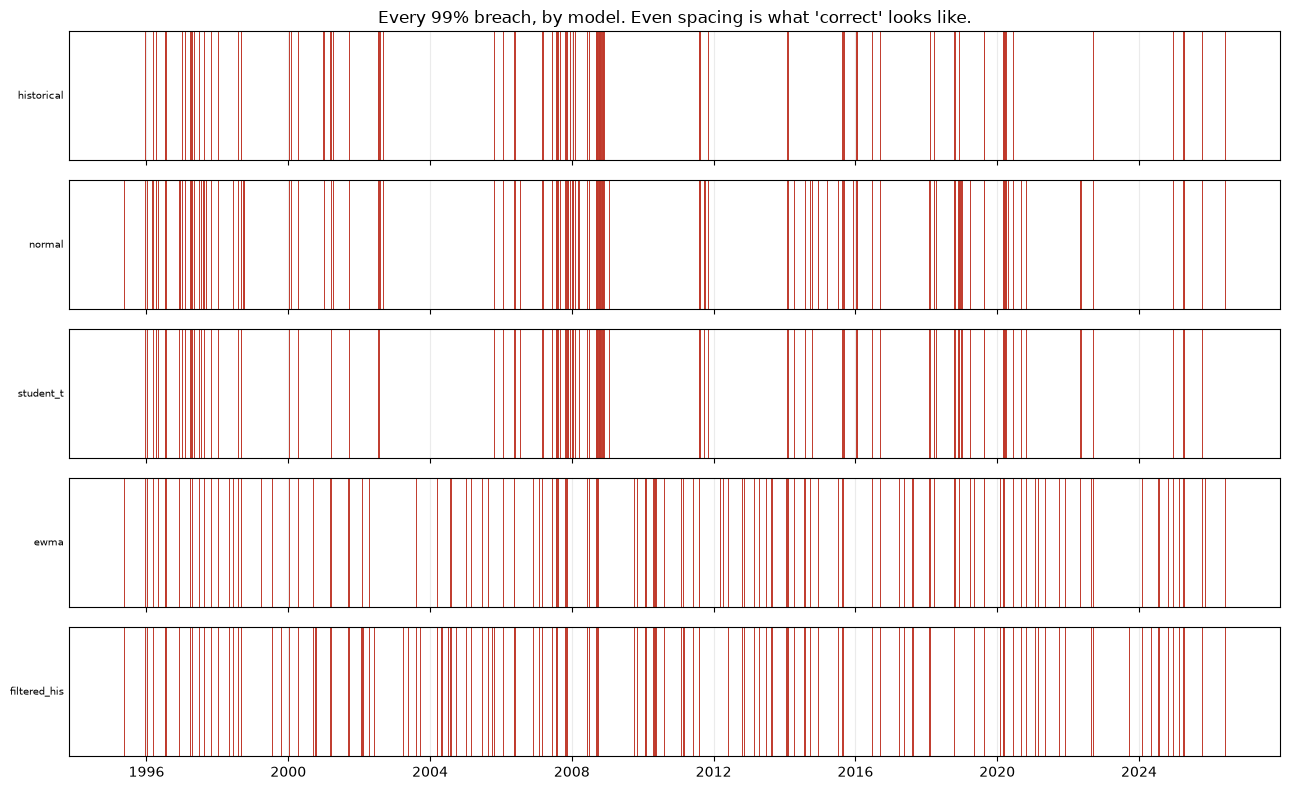

historical             P(breach | breach yesterday) = 8.4%  vs P(breach | no breach) = 1.4%   p = 0.0000
normal                 P(breach | breach yesterday) = 7.9%  vs P(breach | no breach) = 2.1%   p = 0.0001


student_t              P(breach | breach yesterday) = 7.8%  vs P(breach | no breach) = 1.7%   p = 0.0001
ewma                   P(breach | breach yesterday) = 3.6%  vs P(breach | no breach) = 1.9%   p = 0.2000
filtered_historical    P(breach | breach yesterday) = 3.4%  vs P(breach | no breach) = 2.0%   p = 0.2734


In [8]:
fig, axes = plt.subplots(len(st.MODELS), 1, figsize=(13, 8), sharex=True)
for ax, m in zip(axes, st.MODELS):
    b = st.breaches(spy, st.build_var(spy, m, 0.99, 500))
    hit = b[b == 1]
    ax.vlines(hit.index, 0, 1, lw=0.7, color="#c0392b")
    ax.set_yticks([]); ax.set_ylabel(m[:12], fontsize=7, rotation=0, ha="right", va="center")
    ax.set_ylim(0, 1)
axes[0].set_title("Every 99% breach, by model. Even spacing is what 'correct' looks like.")
plt.tight_layout(); plt.show()
for m in st.MODELS:
    b = st.breaches(spy, st.build_var(spy, m, 0.99, 500))
    c = st.christoffersen_independence(b)
    print(f"{m:22s} P(breach | breach yesterday) = {c['pi11']:.1%}  vs "
          f"P(breach | no breach) = {c['pi01']:.1%}   p = {c['p_value']:.4f}")

> \U0001F4A1 **In plain words.** Under a correct model those two conditional probabilities should
> both be 1%. When the first is five or ten times the second, a breach today genuinely does
> predict a breach tomorrow — the model is not reacting to the regime it is in.

### 3.4 The magnitude of the misses

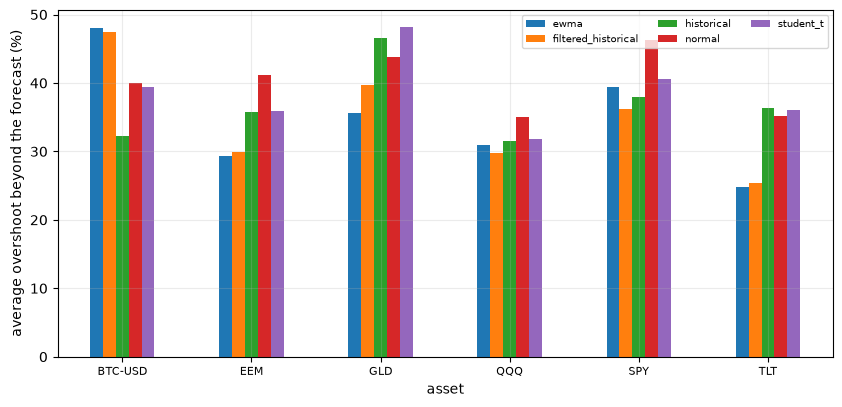

,mean_excess_pct_of_var,max_excess_pct_of_var
model,,
ewma,0.3470,2.5640
filtered_historical,0.3480,2.6940
historical,0.3670,2.5100
normal,0.4020,3.0820
student_t,0.3870,2.6980


In [9]:
rows = []
for tk, s in assets.items():
    for m in st.MODELS:
        w = st.worst_breach_stats(s, st.build_var(s, m, 0.99, 500))
        if "worst_loss" not in w:
            continue
        rows.append({"asset": tk, "model": m, **w})
d3 = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d3.pivot(index="asset", columns="model", values="mean_excess_pct_of_var").mul(100).plot.bar(
    ax=ax)
ax.set_ylabel("average overshoot beyond the forecast (%)")
ax.legend(fontsize=7, ncol=3, title="")
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)
plt.show()
d3.groupby("model")[["mean_excess_pct_of_var", "max_excess_pct_of_var"]].mean().round(3)

### 3.5 The power curve — the section that reframes the rest

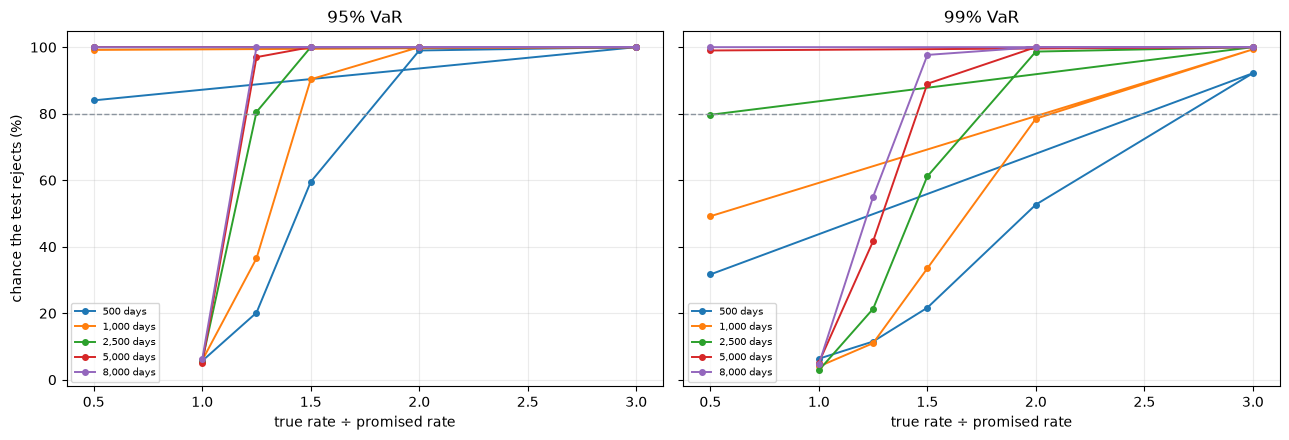

In [10]:
rows = []
for n_days in (500, 1000, 2500, 5000, 8000):
    for lev in (0.95, 0.99):
        pc = st.power_curve(n_days, lev, n_sims=600)
        for tr, rr in pc.iterrows():
            rows.append({"n_days": n_days, "level": lev,
                         "ratio": rr["ratio_to_promised"], "power": rr["reject_rate"]})
d4 = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, lev in zip(axes, (0.95, 0.99)):
    sl = d4[d4["level"] == lev]
    for n_days, g in sl.groupby("n_days"):
        ax.plot(g["ratio"], g["power"] * 100, "o-", lw=1.4, ms=4, label=f"{n_days:,} days")
    ax.axhline(80, ls="--", color="#8b949e", lw=1)
    ax.set_xlabel("true rate ÷ promised rate"); ax.set_title(f"{lev:.0%} VaR")
    ax.legend(fontsize=7)
axes[0].set_ylabel("chance the test rejects (%)")
plt.tight_layout(); plt.show()

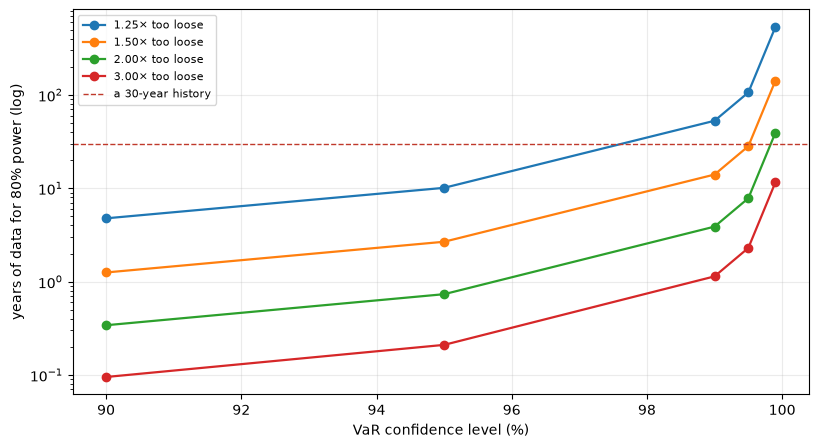

' level  misstatement  sessions    years\n0.9000        1.2000      1201   4.8000\n0.9000        1.5000       316   1.3000\n0.9000        2.0000        86   0.3000\n0.9000        3.0000        24   0.1000\n1.0000        1.2000      2548  10.1000\n1.0000        1.5000       674   2.7000\n1.0000        2.0000       185   0.7000\n1.0000        3.0000        53   0.2000\n1.0000        1.2000     13320  52.9000\n1.0000        1.5000      3536  14.0000\n1.0000        2.0000       979   3.9000\n1.0000        3.0000       287   1.1000\n1.0000        1.2000     26784 106.3000\n1.0000        1.5000      7114  28.2000\n1.0000        2.0000      1972   7.8000\n1.0000        3.0000       579   2.3000\n1.0000        1.2000    134501 533.7000\n1.0000        1.5000     35737 141.8000\n1.0000        2.0000      9911  39.3000\n1.0000        3.0000      2915  11.6000'

In [11]:
rows = []
for lev in (0.90, 0.95, 0.99, 0.995, 0.999):
    for mis in (1.25, 1.5, 2.0, 3.0):
        dd = st.days_needed(lev, mis)
        rows.append({"level": lev, "misstatement": mis, "sessions": dd,
                     "years": dd / 252})
d5 = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 5))
for mis, g in d5.groupby("misstatement"):
    ax.plot(g["level"] * 100, g["years"], "o-", lw=1.6, label=f"{mis:.2f}× too loose")
ax.set_yscale("log"); ax.set_xlabel("VaR confidence level (%)")
ax.set_ylabel("years of data for 80% power (log)")
ax.axhline(30, ls="--", color="#c0392b", lw=1, label="a 30-year history")
ax.legend(fontsize=8)
plt.show()
d5.round(1).to_string(index=False)

> \U0001F4A1 **In plain words.** The red line is roughly all the data that exists for most
> assets. Anything above it is a question that cannot be answered by counting breaches, no
> matter how carefully. That is an argument for testing at lower confidence levels and for
> using measures that extract more information per observation than a binary hit.

### 3.6 Synthetic control: grading against a known truth

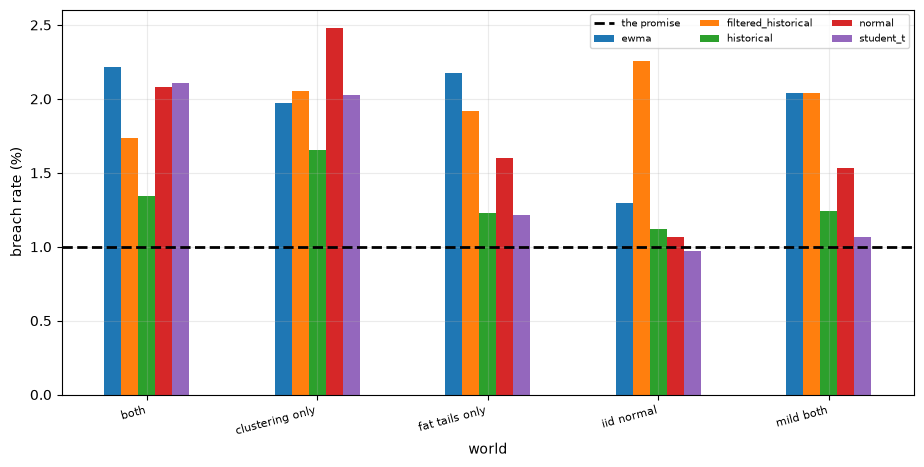

model,ewma,filtered_historical,historical,normal,student_t
world,,,,,
both,0.0221,0.0173,0.0135,0.0208,0.0211
clustering only,0.0197,0.0205,0.0165,0.0248,0.0203
fat tails only,0.0217,0.0192,0.0123,0.0160,0.0121
iid normal,0.0129,0.0225,0.0112,0.0107,0.0097
mild both,0.0204,0.0204,0.0124,0.0153,0.0107


In [12]:
rows = []
for dft, clus, tag in ((1000, 0.0, "iid normal"), (3.0, 0.0, "fat tails only"),
                       (1000, 0.98, "clustering only"), (3.0, 0.98, "both"),
                       (5.0, 0.90, "mild both")):
    sim = st.synthetic_returns(n=8000, df_t=dft, clustering=clus)
    for m in st.MODELS:
        g = st.grade_model(sim, m, 0.99)
        rows.append({"world": tag, "model": m, "rate": g["rate"],
                     "kupiec_p": g["kupiec_p"], "indep_p": g["independence_p"]})
d6 = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5))
piv = d6.pivot(index="world", columns="model", values="rate").mul(100)
piv.plot.bar(ax=ax)
ax.axhline(1.0, color="k", ls="--", lw=2, label="the promise")
ax.set_ylabel("breach rate (%)"); ax.legend(fontsize=7, ncol=3, title="")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
plt.show()
d6.pivot(index="world", columns="model", values="rate").round(4)

## 4 · The verdict

In [13]:
rows = []
for tk, s in assets.items():
    for m in st.MODELS:
        rows.append({"asset": tk, "model": m, **st.grade_model(s, m, 0.99, 500)})
d = pd.DataFrame(rows)
summ = d.groupby("model").agg(mean_rate=("rate", "mean"),
                              kupiec_rejects=("kupiec_p", lambda x: (x < 0.05).mean()),
                              indep_rejects=("independence_p", lambda x: (x < 0.05).mean()),
                              joint_passes=("joint_p", lambda x: (x >= 0.05).mean()))
print(summ.round(4).to_string())
pc = st.power_curve(int(d["n"].median()), 0.99, n_sims=800)
pd.DataFrame({
    "assets": [len(assets)],
    "normal model breach rate": [summ.loc["normal", "mean_rate"]],
    "normal: share of assets Kupiec rejects": [summ.loc["normal", "kupiec_rejects"]],
    "normal: share independence rejects": [summ.loc["normal", "indep_rejects"]],
    "best model": [summ["joint_passes"].idxmax()],
    "best joint-pass share": [summ["joint_passes"].max()],
    "power against a 1.5x-loose model": [
        float(pc[np.isclose(pc["ratio_to_promised"], 1.5)]["reject_rate"].iloc[0])],
    "sessions needed for that": [st.days_needed(0.99, 1.5)],
}).T.rename(columns={0: "value"}).round(4)

                     mean_rate  kupiec_rejects  indep_rejects  joint_passes
model                                                                      
ewma                    0.0179          0.8333         0.0000        0.1667
filtered_historical     0.0206          1.0000         0.0000        0.0000
historical              0.0134          0.5000         1.0000        0.0000
normal                  0.0195          1.0000         0.8333        0.0000
student_t               0.0145          0.5000         1.0000        0.0000


,value
assets,6
normal model breach rate,0.0195
normal: share of assets Kupiec rejects,1.0000
normal: share independence rejects,0.8333
best model,ewma
best joint-pass share,0.1667
power against a 1.5x-loose model,0.8788
sessions needed for that,3536


## 5 · Going further

- **Duration-based tests** (Christoffersen & Pelletier 2004) use the *gaps* between breaches and
  catch clustering at horizons the lag-one Markov test cannot see. The single most valuable
  addition here.
- **Estimation risk.** Escanciano & Olmo (2010) show that treating the VaR forecast as known
  makes these tests over-reject. Correcting for it would soften some of section 3.1's verdicts.
- **Expected shortfall backtesting** (Acerbi & Székely 2014) extracts far more information per
  observation than a binary hit, which is the real answer to the power problem in 3.5.
- **A window sweep.** Everything here uses 500 sessions. Shorter windows react faster and
  estimate the tail worse; that trade-off deserves its own study.